Installs and Imports

In [1]:
!pip install datasets scikit-learn torch transformers --quiet

import os
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.feature_extraction import DictVectorizer

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from transformers import BertTokenizer, BertModel

Loading dataset

In [2]:
from datasets import load_dataset
import pandas as pd

# Load the tweet_eval sentiment dataset, which is a 3-class sentiment dataset
dataset = load_dataset("tweet_eval", "sentiment")

# The dataset already has train, validation, and test splits
train_df = pd.DataFrame(dataset['train'])
dev_df = pd.DataFrame(dataset['validation'])
test_df = pd.DataFrame(dataset['test'])

train_df.head()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

sentiment/train-00000-of-00001.parquet:   0%|          | 0.00/3.78M [00:00<?, ?B/s]

sentiment/test-00000-of-00001.parquet:   0%|          | 0.00/901k [00:00<?, ?B/s]

sentiment/validation-00000-of-00001.parq(…):   0%|          | 0.00/167k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/45615 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/12284 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

,text,label
0,"""QT @user In the original draft of the 7th boo...",2
1,"""Ben Smith / Smith (concussion) remains out of...",1
2,Sorry bout the stream last night I crashed out...,1
3,Chase Headley's RBI double in the 8th inning o...,1
4,@user Alciato: Bee will invest 150 million in ...,2


In [3]:
# The 'tweet_eval' dataset uses numerical labels (0, 1, 2)
# 0: negative, 1: neutral, 2: positive

label_names = {
    0: "negative",
    1: "neutral",
    2: "positive"
}

train_df["label_id"] = train_df["label"]
dev_df["label_id"] = dev_df["label"]
test_df["label_id"] = test_df["label"]

train_df["label_name"] = train_df["label_id"].map(label_names)
dev_df["label_name"] = dev_df["label_id"].map(label_names)
test_df["label_name"] = test_df["label_id"].map(label_names)

train_df.head()

,text,label,label_id,label_name
0,"""QT @user In the original draft of the 7th boo...",2,2,positive
1,"""Ben Smith / Smith (concussion) remains out of...",1,1,neutral
2,Sorry bout the stream last night I crashed out...,1,1,neutral
3,Chase Headley's RBI double in the 8th inning o...,1,1,neutral
4,@user Alciato: Bee will invest 150 million in ...,2,2,positive


In [4]:
print("Train size:", len(train_df))
print("Dev size:", len(dev_df))
print("Test size:", len(test_df))

print("\nClass distribution (Train):")
print(train_df["label_name"].value_counts())

Train size: 45615
Dev size: 2000
Test size: 12284

Class distribution (Train):
label_name
neutral     20673
positive    17849
negative     7093
Name: count, dtype: int64


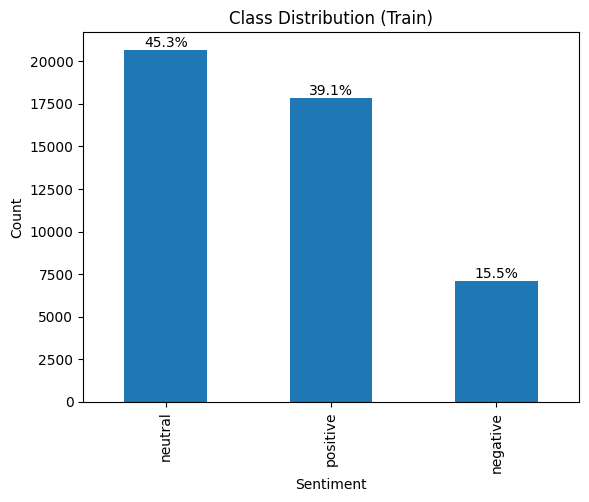

In [5]:
import matplotlib.pyplot as plt

counts = train_df["label_name"].value_counts()

counts.plot(kind="bar")
plt.title("Class Distribution (Train)")
plt.xlabel("Sentiment")
plt.ylabel("Count")

total = len(train_df)
for i, v in enumerate(counts):
    plt.text(i, v + 200, f"{(v/total)*100:.1f}%", ha='center')

plt.show()

In [6]:
for i in range(5):
    print(f"Text: {train_df.iloc[i]['text']}")
    print(f"Label: {train_df.iloc[i]['label_name']}")
    print("-" * 50)

Text: "QT @user In the original draft of the 7th book, Remus Lupin survived the Battle of Hogwarts. #HappyBirthdayRemusLupin"
Label: positive
--------------------------------------------------
Text: "Ben Smith / Smith (concussion) remains out of the lineup Thursday, Curtis #NHL #SJ"
Label: neutral
--------------------------------------------------
Text: Sorry bout the stream last night I crashed out but will be on tonight for sure. Then back to Minecraft in pc tomorrow night.
Label: neutral
--------------------------------------------------
Text: Chase Headley's RBI double in the 8th inning off David Price snapped a Yankees streak of 33 consecutive scoreless innings against Blue Jays
Label: neutral
--------------------------------------------------
Text: @user Alciato: Bee will invest 150 million in January, another 200 in the Summer and plans to bring Messi by 2017"
Label: positive
--------------------------------------------------


Feature Engineering + Softmax (Improved Baseline)

We will:
- Clean text (important for tweets)
- Extract unigram features
- Handle class imbalance
- Train Logistic Regression

In [7]:
import re

def clean_text(text):
    text = text.lower()

    text = re.sub(r"http\S+|www\S+", "", text)

    text = re.sub(r"@\w+", "", text)

    text = re.sub(r"#", "", text)

    text = re.sub(r"[^\w\s]", "", text)

    return text

In [8]:
train_df["clean_text"] = train_df["text"].apply(clean_text)
dev_df["clean_text"] = dev_df["text"].apply(clean_text)
test_df["clean_text"] = test_df["text"].apply(clean_text)

In [9]:
def unigram_phi(text):
    features = {}
    for word in text.split():
        features[word] = features.get(word, 0) + 1
    return features

In [10]:
from sklearn.feature_extraction import DictVectorizer

vectorizer = DictVectorizer()

X_train_dict = [unigram_phi(text) for text in train_df["clean_text"]]
X_train = vectorizer.fit_transform(X_train_dict)

y_train = train_df["label_id"].values

In [11]:
X_dev_dict = [unigram_phi(text) for text in dev_df["clean_text"]]
X_dev = vectorizer.transform(X_dev_dict)

y_dev = dev_df["label_id"].values

In [12]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weight_dict = {i: class_weights[i] for i in range(len(classes))}

print("Class Weights:", class_weight_dict)

Class Weights: {0: np.float64(2.14366276610743), 1: np.float64(0.7355004111643206), 2: np.float64(0.8518684520141184)}


In [13]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(
    max_iter=1000,
    class_weight=class_weight_dict
)

clf.fit(X_train, y_train)

LogisticRegression(class_weight={0: np.float64(2.14366276610743),
                                 1: np.float64(0.7355004111643206),
                                 2: np.float64(0.8518684520141184)},
                   max_iter=1000)

In [14]:
from sklearn.metrics import accuracy_score

y_pred = clf.predict(X_dev)

accuracy = accuracy_score(y_dev, y_pred)
print("Dev Accuracy:", accuracy)

Dev Accuracy: 0.6525


In [15]:
from sklearn.metrics import classification_report

print(classification_report(y_dev, y_pred, target_names=["negative", "neutral", "positive"]))

              precision    recall  f1-score   support

    negative       0.49      0.62      0.55       312
     neutral       0.66      0.63      0.64       869
    positive       0.73      0.69      0.71       819

    accuracy                           0.65      2000
   macro avg       0.63      0.65      0.63      2000
weighted avg       0.66      0.65      0.66      2000



In [16]:
for i in range(5):
    print("Text:", dev_df.iloc[i]["text"])
    print("True:", label_names[y_dev[i]])
    print("Pred:", label_names[y_pred[i]])
    print("-" * 50)

Text: Dark Souls 3 April Launch Date Confirmed With New Trailer: Embrace the darkness.
True: neutral
Pred: neutral
--------------------------------------------------
Text: "National hot dog day, national tequila day, then national dance day... Sounds like a Friday night."
True: positive
Pred: positive
--------------------------------------------------
Text: When girls become bandwagon fans of the Packers because of Harry.   Do y'all even know who Aaron Rodgers is?  Or what a 1st down is?
True: negative
Pred: negative
--------------------------------------------------
Text: @user I may or may not have searched it up on google
True: neutral
Pred: neutral
--------------------------------------------------
Text: Here's your starting TUESDAY MORNING Line up at  Gentle Yoga with Laura 9:30 am to 10:30 am...
True: neutral
Pred: neutral
--------------------------------------------------


In [17]:
errors = []

for i in range(len(dev_df)):
    if y_pred[i] != y_dev[i]:
        errors.append({
            "text": dev_df.iloc[i]["text"],
            "true": label_names[y_dev[i]],
            "pred": label_names[y_pred[i]]
        })

len(errors)

695

In [18]:
for i in range(10):
    print("Text:", errors[i]["text"])
    print("True:", errors[i]["true"])
    print("Pred:", errors[i]["pred"])
    print("-" * 60)

Text: @user so the thing next Thursday isn't free, you'd have to pay $15 to get in since you don't go to UMBC :/ and it ends at 11:30"
True: negative
Pred: neutral
------------------------------------------------------------
Text: RT @user Republicans thought they were smart to move Obama's speech but he'll now have a bigger audience Thurs. because he'll  ...
True: neutral
Pred: negative
------------------------------------------------------------
Text: F*** the hurricane party this Tues santospartyhaus w/ @user @user @user @ Santos Party House
True: negative
Pred: neutral
------------------------------------------------------------
Text: Tom Brady is locked for Thursday. Let the season begin! #RepeatSeason
True: positive
Pred: neutral
------------------------------------------------------------
Text: In this second time I've watched Ant-Man and this time I was the only one that stayed for the 2nd after credits scene
True: neutral
Pred: positive
----------------------------------------

In [19]:
from collections import Counter

error_types = Counter()

for e in errors:
    error_types[(e["true"], e["pred"])] += 1

error_types

Counter({('negative', 'neutral'): 88,
         ('neutral', 'negative'): 140,
         ('positive', 'neutral'): 191,
         ('neutral', 'positive'): 183,
         ('positive', 'negative'): 63,
         ('negative', 'positive'): 30})

# RNN Model

We now build a Recurrent Neural Network to:
- Capture word order
- Understand context better than Bag-of-Words

In [20]:
from collections import Counter

def tokenize(text):
    return text.split()

word_counts = Counter()

for text in train_df["clean_text"]:
    word_counts.update(tokenize(text))

vocab_size = 10000
most_common = word_counts.most_common(vocab_size)

word2idx = {word: i+2 for i, (word, _) in enumerate(most_common)}
word2idx["<PAD>"] = 0
word2idx["<UNK>"] = 1

idx2word = {i: w for w, i in word2idx.items()}

In [21]:
max_len = 30

def encode(text):
    tokens = tokenize(text)
    encoded = [word2idx.get(word, 1) for word in tokens]

    if len(encoded) < max_len:
        encoded += [0] * (max_len - len(encoded))
    else:
        encoded = encoded[:max_len]

    return encoded

In [22]:
class SentimentDataset(Dataset):
    def __init__(self, df):
        self.texts = df["clean_text"].tolist()
        self.labels = df["label_id"].tolist()

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        x = torch.tensor(encode(self.texts[idx]), dtype=torch.long)
        y = torch.tensor(self.labels[idx], dtype=torch.long)
        return x, y

In [23]:
batch_size = 64

train_dataset = SentimentDataset(train_df)
dev_dataset = SentimentDataset(dev_df)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
dev_loader = DataLoader(dev_dataset, batch_size=batch_size)

In [24]:
class RNNModel(nn.Module):
    def __init__(self, vocab_size, embed_dim=100, hidden_dim=128):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.rnn = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 3)

    def forward(self, x):
        x = self.embedding(x)
        _, (h, _) = self.rnn(x)
        out = self.fc(h[-1])
        return out

In [25]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = RNNModel(len(word2idx)).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [26]:
def train_model(model, loader):
    model.train()
    total_loss = 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        outputs = model(x)
        loss = criterion(outputs, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

In [27]:
def evaluate_model(model, loader):
    model.eval()
    preds = []
    true = []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            outputs = model(x)
            predicted = torch.argmax(outputs, dim=1).cpu().numpy()

            preds.extend(predicted)
            true.extend(y.numpy())

    return preds, true

In [28]:
epochs = 10

for epoch in range(epochs):
    loss = train_model(model, train_loader)
    print(f"Epoch {epoch+1}, Loss: {loss:.4f}")

Epoch 1, Loss: 0.9702
Epoch 2, Loss: 0.8363
Epoch 3, Loss: 0.7410
Epoch 4, Loss: 0.6648
Epoch 5, Loss: 0.5938
Epoch 6, Loss: 0.5203
Epoch 7, Loss: 0.4477
Epoch 8, Loss: 0.3752
Epoch 9, Loss: 0.3112
Epoch 10, Loss: 0.2571


In [29]:
rnn_preds, rnn_true = evaluate_model(model, dev_loader)

from sklearn.metrics import accuracy_score, classification_report

print("RNN Accuracy:", accuracy_score(rnn_true, rnn_preds))
print(classification_report(rnn_true, rnn_preds, target_names=["negative","neutral","positive"]))

RNN Accuracy: 0.64
              precision    recall  f1-score   support

    negative       0.50      0.53      0.52       312
     neutral       0.65      0.62      0.63       869
    positive       0.69      0.70      0.70       819

    accuracy                           0.64      2000
   macro avg       0.61      0.62      0.61      2000
weighted avg       0.64      0.64      0.64      2000



BiLSTM

We improve the RNN using:
- Bidirectional LSTM
- Dropout regularization
- Better sequence representation

In [30]:
class BiLSTMModel(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=128):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

        self.lstm = nn.LSTM(
            embed_dim,
            hidden_dim,
            batch_first=True,
            bidirectional=True
        )

        self.dropout = nn.Dropout(0.5)

        self.fc = nn.Linear(hidden_dim * 2, 3)

    def forward(self, x):
        x = self.embedding(x)

        _, (h, _) = self.lstm(x)

        h = torch.cat((h[-2], h[-1]), dim=1)

        h = self.dropout(h)

        out = self.fc(h)

        return out

In [31]:
model = BiLSTMModel(len(word2idx)).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [32]:
epochs = 10

for epoch in range(epochs):
    loss = train_model(model, train_loader)
    print(f"Epoch {epoch+1}, Loss: {loss:.4f}")

Epoch 1, Loss: 0.9168
Epoch 2, Loss: 0.7711
Epoch 3, Loss: 0.6706
Epoch 4, Loss: 0.5821
Epoch 5, Loss: 0.4918
Epoch 6, Loss: 0.4001
Epoch 7, Loss: 0.3132
Epoch 8, Loss: 0.2419
Epoch 9, Loss: 0.1807
Epoch 10, Loss: 0.1434


In [33]:
bilstm_preds, bilstm_true = evaluate_model(model, dev_loader)

from sklearn.metrics import accuracy_score, classification_report

print("BiLSTM Accuracy:", accuracy_score(bilstm_true, bilstm_preds))
print(classification_report(bilstm_true, bilstm_preds, target_names=["negative","neutral","positive"]))

BiLSTM Accuracy: 0.6435
              precision    recall  f1-score   support

    negative       0.50      0.44      0.47       312
     neutral       0.62      0.71      0.66       869
    positive       0.74      0.66      0.69       819

    accuracy                           0.64      2000
   macro avg       0.62      0.60      0.61      2000
weighted avg       0.65      0.64      0.64      2000



BERT Model (Final Model)

We use a pretrained transformer (BERT) and fine-tune it for sentiment classification.

In [34]:
from datasets import Dataset

train_bert = Dataset.from_pandas(train_df[["text", "label_id"]])
dev_bert = Dataset.from_pandas(dev_df[["text", "label_id"]])
test_bert = Dataset.from_pandas(test_df[["text", "label_id"]])

In [35]:
from transformers import BertTokenizer

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

def tokenize_function(example):
    return tokenizer(
        example["text"],
        padding="max_length",
        truncation=True,
        max_length=64
    )

train_bert = train_bert.map(tokenize_function, batched=True)
dev_bert = dev_bert.map(tokenize_function, batched=True)
test_bert = test_bert.map(tokenize_function, batched=True)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/45615 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/12284 [00:00<?, ? examples/s]

In [36]:
train_bert = train_bert.rename_column("label_id", "labels")
dev_bert = dev_bert.rename_column("label_id", "labels")
test_bert = test_bert.rename_column("label_id", "labels")

train_bert.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
dev_bert.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
test_bert.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

In [37]:
from transformers import BertForSequenceClassification

model_bert = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=3
)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [38]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="no",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=2,
    logging_dir="./logs",
    logging_steps=100
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [39]:
import numpy as np
from sklearn.metrics import accuracy_score

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {"accuracy": accuracy_score(labels, preds)}

In [40]:
from transformers import Trainer

trainer = Trainer(
    model=model_bert,
    args=training_args,
    train_dataset=train_bert,
    eval_dataset=dev_bert,
    compute_metrics=compute_metrics
)

In [41]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,0.592581,0.598032,0.741500
2,0.483897,0.633708,0.749000


TrainOutput(global_step=5702, training_loss=0.5546223030555294, metrics={'train_runtime': 1203.4665, 'train_samples_per_second': 75.806, 'train_steps_per_second': 4.738, 'total_flos': 3000479637415680.0, 'train_loss': 0.5546223030555294, 'epoch': 2.0})

In [42]:
bert_results = trainer.evaluate()
print("BERT Accuracy:", bert_results["eval_accuracy"])

BERT Accuracy: 0.749


In [43]:
preds_output = trainer.predict(dev_bert)

bert_preds = np.argmax(preds_output.predictions, axis=1)
bert_true = preds_output.label_ids

In [44]:
from sklearn.metrics import classification_report

print(classification_report(bert_true, bert_preds, target_names=["negative","neutral","positive"]))

              precision    recall  f1-score   support

    negative       0.64      0.69      0.66       312
     neutral       0.74      0.72      0.73       869
    positive       0.80      0.81      0.80       819

    accuracy                           0.75      2000
   macro avg       0.73      0.74      0.73      2000
weighted avg       0.75      0.75      0.75      2000



In [46]:
def predict_text(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True)

    # Move input tensors to the same device as the model
    inputs = {k: v.to(device) for k, v in inputs.items()}

    outputs = model_bert(**inputs)
    probs = torch.nn.functional.softmax(outputs.logits, dim=1)

    pred = torch.argmax(probs).item()

    return label_names[pred]

# Try examples
samples = [
    "I absolutely love this!",
    "This is okay, nothing special",
    "This is the worst thing ever"
]

for s in samples:
    print(s, "→", predict_text(s))

I absolutely love this! → positive
This is okay, nothing special → positive
This is the worst thing ever → negative


Final Models Comparison

In [47]:
print("==== FINAL MODEL COMPARISON ====")

print(f"Logistic Regression Accuracy: {accuracy:.4f}")
print(f"RNN Accuracy: {accuracy_score(rnn_true, rnn_preds):.4f}")
print(f"BiLSTM Accuracy: {accuracy_score(bilstm_true, bilstm_preds):.4f}")
print(f"BERT Accuracy: {bert_results['eval_accuracy']:.4f}")

==== FINAL MODEL COMPARISON ====
Logistic Regression Accuracy: 0.6525
RNN Accuracy: 0.6400
BiLSTM Accuracy: 0.6435
BERT Accuracy: 0.7490
